<a href="https://colab.research.google.com/github/raisharad/GenerativeAIandAgenticAI/blob/main/PEFT_Prefix_Tuning_C2_Demo2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##<font color="blue"><b>-----Prefix Tuning for Multiple Tasks with One Frozen Model-----</b></font>

### <font color="purple">**Problem Statement**</font>

In this demo, we are going to learn about **Prefix Tuning**. Prefix Tuning was introduced by [**Li and Liang in 2021**](https://arxiv.org/abs/2101.00190) as a way to adapt a pretrained language model without updating all of its parameters.

Here, we will use a **frozen GPT-2 Medium** model and adapt it to two different **table-to-text generation tasks**.

The first task is **E2E**, where the input contains information about a restaurant and the model generates a natural-language restaurant description.

| Input                                                              | Output                                                                        |
| ------------------------------------------------------------------ | ----------------------------------------------------------------------------- |
| `name[The Eagle], food[Italian], area[city centre], price[20]`     | The Eagle is an Italian restaurant in the city centre, priced at £20.         |
| `name[The Golden Curry], food[Indian], area[riverside], price[35]` | The Golden Curry is an Indian restaurant by the riverside, priced at £35.     |
| `name[The Green Garden], food[Chinese], area[downtown], price[15]` | The Green Garden is a Chinese restaurant in the downtown area, priced at £15. |



The second task is **DART**, where the input consists of **open-domain triples**, and the model generates a corresponding text description.

| Input                                 | Output                             |
| ------------------------------------- | ---------------------------------- |
| `Paris \| country \| France`          | Paris is a city in France.         |
| `Einstein \| occupation \| physicist` | Einstein was a physicist.          |
| `Everest \| located in \| Nepal`      | Mount Everest is located in Nepal. |


So, by the end of this tutorial, we will see **how Prefix Tuning works and how we can use it to adapt the same frozen GPT-2 model to different tasks**.

### **Prefix Tuning**

<img src="https://raw.githubusercontent.com/Rekha215/Demo-Images/refs/heads/main/prefix_tuning_idea.png" width="600">

-------------

In [ ]:
!pip install -q nltk

In [ ]:
import gc
import re
import math
import random
import warnings
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from safetensors.torch import load_file
from torch.utils.data import TensorDataset, Dataset
from nltk.translate.bleu_score import corpus_bleu
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, PrinterCallback
from peft import PrefixTuningConfig, TaskType, get_peft_model, PeftModel

In [ ]:
warnings.filterwarnings("ignore")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

### Prefix tuning - (slide)
<img src="https://raw.githubusercontent.com/Rekha215/Demo-Images/refs/heads/main/MLP_prefix.png" width="600">

In [ ]:
MODEL_NAME      = "gpt2-medium"
PREFIX_LEN      = {"e2e": 5, "dart": 10}
MLP_HIDDEN      = 512        # k in image

N_TRAIN         = 2000       # per task
N_VAL           = 300        # per task
N_EVAL          = 100        # per task

MAX_SRC_TOKENS  = 96
MAX_TGT_TOKENS  = 64

MAX_LEN         = 192
MAX_NEW_TOKENS  = 64

NUM_BEAMS       = 1          # beam 5; greedy here for speed
IGNORE_INDEX    = -100       # ignore during loss computation
EPOCHS          = 5          # 10
BATCH_SIZE      = 16
LR              = 5e-4       # 5e-5 / 8e-5
WARMUP_FRAC     = 0.1
SEED            = 42

In [ ]:
set_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

Device: cuda


config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
# ===========================================================================
# Load E2E and DART from their official repositories, linearize the tables
# ===========================================================================
E2E_URL  = "https://raw.githubusercontent.com/tuetschek/e2e-dataset/master/"
DART_URL = "https://raw.githubusercontent.com/Yale-LILY/dart/master/data/v1.1.1/"

def linearize_e2e(mr):
    return " | ".join(f"{k.strip()} : {v.strip()}" for k, v in re.findall(r"([^,\[]+)\[([^\]]*)\]", mr))

def linearize_dart(tripleset):
    return " | ".join(" : ".join(t) for t in tripleset)

def load_e2e(file):
    df = pd.read_csv(E2E_URL + file)
    return pd.DataFrame({"source": df.mr.map(linearize_e2e), "target": df.ref})

def load_dart(split):
    df = pd.read_json(DART_URL + f"dart-v1.1.1-full-{split}.json")
    return pd.DataFrame([{"source": linearize_dart(ts), "target": a["text"]}
                         for ts, anns in zip(df.tripleset, df.annotations)
                         for a in anns if a["source"] != "e2e"])     # keep DART distinct from E2E

# groups multiple reference texts (target) that belong to the same source
def group_refs(df):
    return df.groupby("source", sort=False)["target"].apply(list).reset_index(name="refs")

tasks = {
    "e2e": {
        "train": load_e2e("trainset.csv").sample(n=N_TRAIN, random_state=SEED),
        "val":   load_e2e("devset.csv").sample(n=N_VAL, random_state=SEED),
        "test":  group_refs(load_e2e("testset_w_refs.csv")).sample(n=N_EVAL, random_state=SEED),
    },
    "dart": {
        "train": load_dart("train").sample(n=N_TRAIN, random_state=SEED),
        "val":   load_dart("dev").sample(n=N_VAL, random_state=SEED),
        "test":  group_refs(load_dart("test")).sample(n=N_EVAL, random_state=SEED),
    },
}

In [ ]:
from IPython.display import display

# E2E
e2e = tasks["e2e"]
print("E2E")
print("Train:", len(e2e["train"]))
print("Validation:", len(e2e["val"]))
print("Test:", len(e2e["test"]))
print("Average references:", e2e["test"]["refs"].map(len).mean())

display(e2e["train"][["source", "target"]].head().style.set_properties(**{"white-space": "normal","vertical-align": "top"}))

E2E
Train: 2000
Validation: 300
Test: 100
Average references: 7.04


,source,target
21771,name : The Eagle | eatType : coffee shop | food : Italian | priceRange : less than £20 | customer rating : low | area : riverside | familyFriendly : yes | near : Burger King,"There is an inexpensive, family-friendly coffee shop near the river and Burger King. It's called The Eagle and serves pasta."
1414,name : Clowns | eatType : coffee shop | food : Italian | customer rating : average | area : city centre | near : Clare Hall,An Italian coffee shop with an average customer rating. Clowns is located near Clare Hall in the city centre.
7390,name : Browns Cambridge | food : English | area : riverside | familyFriendly : yes | near : The Sorrento,The Browns Cambridge is a family friendly English restaurant in riverside near The Sorrento.
9845,name : The Punter | eatType : coffee shop | food : French | priceRange : less than £20 | customer rating : low | familyFriendly : no | near : Café Sicilia,The Punter coffee shop has only a one star rating and does not appear to be family oriented . They are located near Café Sicilia
26578,name : Fitzbillies | eatType : coffee shop | food : French | priceRange : high | customer rating : 3 out of 5 | area : riverside | familyFriendly : yes,Fitzbillies is a coffee shop near the riverside. They are family friendly and serve food. They have a high price and have a 3 out of 5 star rating.


In [ ]:
# DART
dart = tasks["dart"]

print("\nDART")
print("Train:", len(dart["train"]))
print("Validation:", len(dart["val"]))
print("Test:", len(dart["test"]))
print("Average references:", dart["test"]["refs"].map(len).mean())

display(dart["train"][["source", "target"]].head().style.set_properties(**{"white-space": "normal","vertical-align": "top"}))


DART
Train: 2000
Validation: 300
Test: 100
Average references: 3.18


,source,target
8978,Five Weeks in a Balloon : WRITER : Yes | [TABLECONTEXT] : [TITLE] : Irwin Allen | Five Weeks in a Balloon : PRODUCER : Yes | Five Weeks in a Balloon : YEAR : 1962 | [TABLECONTEXT] : FILM : Five Weeks in a Balloon,"Irwin Allen is the writer and producer of Five Weeks in a Balloon, a 1962 movie."
22962,"Bacon Explosion : COUNTRY : United States | Bacon Explosion : MAIN_INGREDIENTS : ""Bacon,sausage"" | Bacon Explosion : INGREDIENT : Sausage | Bacon Explosion : COURSE : ""Main course"" | Bacon Explosion : MAIN_INGREDIENTS : Bacon",Bacon Explosion is a main course dish from the United States which contains the main ingredients of bacon and sausage.
20216,"Saranac Lake, New York : IS_PART_OF : Harrietstown, New York | Harrietstown, New York : IS_PART_OF : New York | Adirondack Regional Airport : CITY_SERVED : Lake Placid, New York | Adirondack Regional Airport : CITY_SERVED : Saranac Lake, New York | Saranac Lake, New York : COUNTRY : United States","Saranac Lake, New York is located in the United States and is a part of Harrietstown, New York. Adirondack Regional Airport serves both the city of Lake Placid and the city of Saranac Lake in New York."
11617,Massimo Drago : CLUB : U.S. Castrovillari Calcio | A.C. Cesena : MANAGER : Massimo Drago | Massimo Drago : CLUB : Delfino Pescara 1936,Massimo Drago plays for U.S Castrovillari Calcio; he has been the manager of A C Cesena and is attached to the club Delfino Pescara 1936.
18409,"Akita Museum of Art : COUNTRY : Japan | Akita Museum of Art : LOCATION : Akita, Akita | Akita, Akita : IS_PART_OF : Akita Prefecture | Japan : ETHNIC_GROUP : Brazilians in Japan | Japan : LEADER_NAME : Tarō Asō","Akita Museum of Art is an art museum in the city of Akita which is part of Akita Prefecture, Japan. One of the ethnic groups in Japan is the Brazilians and the leader of the country is Tarō Asō."


In [ ]:
# ===========================================================================
# Template:  "Table: {linearized table}\nText:" -> " {description}<eos>"
# ===========================================================================
START_IDS = tokenizer("Table: ")["input_ids"]
END_IDS   = tokenizer("\nText:")["input_ids"]

def encode_prompt(source):
    return START_IDS + tokenizer(source)["input_ids"][:MAX_SRC_TOKENS] + END_IDS

print(tokenizer.decode(encode_prompt(tasks["e2e"]["train"].source.iloc[0])))

Table: name : The Eagle | eatType : coffee shop | food : Italian | priceRange : less than £20 | customer rating : low | area : riverside | familyFriendly : yes | near : Burger King
Text:


In [ ]:
# ===========================================================================
# Build TensorDatasets
#   loss only on " {description}<eos>", prompt masked with -100
# ===========================================================================
def build_dataset(df):
    input_ids_list, attention_list, labels_list = [], [], []

    for source, target in zip(df.source, df.target):
        prompt_ids = encode_prompt(source)
        target_ids = tokenizer(" " + target)["input_ids"][:MAX_TGT_TOKENS] + [tokenizer.eos_token_id]

        full_ids = prompt_ids + target_ids
        labels   = [IGNORE_INDEX] * len(prompt_ids) + target_ids

        # Pad to MAX_LEN
        pad_n     = MAX_LEN - len(full_ids)
        attention = [1] * len(full_ids) + [0] * pad_n
        full_ids  = full_ids + [tokenizer.pad_token_id] * pad_n
        labels    = labels   + [IGNORE_INDEX] * pad_n

        input_ids_list.append(torch.tensor(full_ids))
        attention_list.append(torch.tensor(attention))
        labels_list.append(torch.tensor(labels))

    return TensorDataset(
        torch.stack(input_ids_list),
        torch.stack(attention_list),
        torch.stack(labels_list),
    )

# ===========================================================================
# Wrap TensorDataset -> dict for Trainer
# ===========================================================================
class DictDataset(Dataset):
    def __init__(self, tensor_ds):
        self.ds = tensor_ds
    def __len__(self):
        return len(self.ds)
    def __getitem__(self, i):
        input_ids, attention_mask, labels = self.ds[i]
        return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}

In [ ]:
# ===========================================================================
# Helpers
# ===========================================================================
def weight_checksum(model):
    # model parameters → detach → convert to double → sum each tensor → sum everything
    return sum(p.detach().double().sum().item() for p in model.parameters())

def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def free_gpu():
    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()

def training_log(history):  # tr: train | va: validation
    tr = {round(r["epoch"]): r["eval_train_loss"] for r in history if "eval_train_loss" in r}
    va = {round(r["epoch"]): r["eval_val_loss"]   for r in history if "eval_val_loss" in r}
    return pd.DataFrame([{"Epoch": e, "Train Loss": tr[e], "Val Loss": va[e]} for e in sorted(va)])

@torch.no_grad()
def generate(m, source, first_line=True):
    return generate_batch(m, [source], batch_size=1, first_line=first_line)[0]

@torch.no_grad()
def generate_batch(m, sources, batch_size=32, first_line=True):
    m.eval()
    pad_id = tokenizer.eos_token_id
    results = []
    for i in range(0, len(sources), batch_size):
        prompts = [encode_prompt(s) for s in sources[i:i + batch_size]]
        max_len = max(len(p) for p in prompts)
        input_ids = torch.tensor([[pad_id] * (max_len - len(p)) + p for p in prompts], device=device)
        attn_mask = torch.tensor([[0] * (max_len - len(p)) + [1] * len(p) for p in prompts], device=device)
        out = m.generate(
            input_ids=input_ids,
            attention_mask=attn_mask,
            max_new_tokens=MAX_NEW_TOKENS,
            num_beams=NUM_BEAMS,
            do_sample=False,
            pad_token_id=pad_id,
            eos_token_id=pad_id,
        )
        for seq in out[:, max_len:]:
            text = tokenizer.decode(seq, skip_special_tokens=True).strip()
            results.append(text.split("\n")[0].strip() if first_line else text)
    return results

### <font color="purple"><b>BLEU: Example</b></font>


**Reference:** Paris is a city in France.

**Generated:** Paris is a city of France.

Tokens: Reference = `paris` `is` `a` `city` `in` `france` `.` (7)

Tokens: Generated = `paris` `is` `a` `city` `of` `france` `.` (7)

---

### n = 1: Unigram precision

`Clipped Count = min(Count in Generated, Max Count in Reference)`

| Unigram | Count in Generated | Max Count in Reference | Clipped Count  |
|---|---|---|---|
| paris | 1 | 1 | 1 |
| is | 1 | 1 | 1 |
| a | 1 | 1 | 1 |
| city | 1 | 1 | 1 |
| of | 1 | 0 | 0 |
| france | 1 | 1 | 1 |
| . | 1 | 1 | 1 |
| **Total** | **7** | | **6** |

$p_1 = 6/7 = 0.857$

---

### n = 2: Bigram precision

| Bigram | Count in Generated | Max Count in Reference | Clipped Count |
|---|---|---|---|
| paris is | 1 | 1 | 1 |
| is a | 1 | 1 | 1 |
| a city | 1 | 1 | 1 |
| city of | 1 | 0 | 0 |
| of france | 1 | 0 | 0 |
| france . | 1 | 1 | 1 |
| **Total** | **6** | | **4** |

$p_2 = 4/6 = 0.667$

---

### n = 3: Trigram precision

| Trigram | Count in Generated | Max Count in Reference | Clipped Count |
|---|---|---|---|
| paris is a | 1 | 1 | 1 |
| is a city | 1 | 1 | 1 |
| a city of | 1 | 0 | 0 |
| city of france | 1 | 0 | 0 |
| of france . | 1 | 0 | 0 |
| **Total** | **5** | | **2** |

$p_3 = 2/5 = 0.400$

---

### n = 4: 4-gram precision

| 4-gram | Count in Generated | Max Count in Reference | Clipped Count |
|---|---|---|---|
| paris is a city | 1 | 1 | 1 |
| is a city of | 1 | 0 | 0 |
| a city of france | 1 | 0 | 0 |
| city of france . | 1 | 0 | 0 |
| **Total** | **4** | | **1** |

$p_4 = 1/4 = 0.250$

---

### **BLEU - Formula**

$\text{BLEU} = BP \cdot \exp\left(\sum_{n=1}^{4} w_n \log p_n\right) = BP \times \text{GM}$

where $p_n$ = clipped n-gram precision, $w_n = \tfrac{1}{4}$, $BP$ = brevity penalty

-----------------------

$\text{GM} = \exp\left(\sum_{n=1}^{4} w_n \log p_n\right) = (p_1 \, p_2 \, p_3 \, p_4)^{1/4}$

$\text{GM} = (0.857 \times 0.667 \times 0.400 \times 0.250)^{1/4} = 0.4889$

------------------------
### **Brevity penalty**

$BP = \begin{cases} 1 & \text{if } c > r \\ e^{\,1 - r/c} & \text{if } c \le r \end{cases}$

Generated length $c = 7$, Reference length $r = 7$ → $BP = e^{0} = 1$

------------------------

### **BLEU**

$\text{BLEU} = 1 \times 0.4889 = 0.4889$

----------
In function below:
$\text{BLEU} = 100 \times 0.4889 = 48.89$


In [ ]:
def word_tokens(s):
    return re.findall(r"\w+|[^\w\s]", s.lower())

def score_generation(hyps, refs_list):         # hyps (generated), refs_list (references)
    bleu = corpus_bleu([[word_tokens(r) for r in refs] for refs in refs_list], [word_tokens(h) for h in hyps])
    return 100 * bleu

In [ ]:
# BLEU score caluation of our example in markdown
score_generation(["Paris is a city of France."], [["Paris is a city in France."]])   # -> 48.89

48.8923022434901

### <font color="purple">**An annotated example of prefix-tuning using an autoregressive LM (GPT2)**</font>

<img src="https://raw.githubusercontent.com/Rekha215/Demo-Images/refs/heads/main/prefix_gpt2.png" width="800">


- **PREFIX** (positions P<sub>idx</sub>): virtual tokens with no real words.
- **x** (source table) and **y** (target text): real tokens, processed by the **frozen** GPT-2.
- **Loss:** computed only on **y**, the description.



The activation at each position i is:

$$
h_i =
\begin{cases}
P_\theta[i,:], & \text{if } i \in \mathrm{P_{idx}} \quad \text{(prefix: taken from a trainable matrix)} \\
\mathrm{LM}_\phi(z_i,\, h_{<i}), & \text{otherwise} \quad \text{(real token: computed by frozen GPT-2)}
\end{cases}
$$

- $P_\theta$: the **trainable prefix matrix** (θ = prefix parameters). Each row holds a virtual token's **key/value vectors for all layers**.
- $\mathrm{LM}_\phi$: **frozen GPT-2** (φ = GPT-2 weights, never updated).
- $h_{<i}$: all earlier activations, **including the prefix**. So even though φ is frozen, every table and description token depends on $P_\theta$, because the prefix is always to its left.

In [ ]:
# ===========================================================================
# Reusable training: fresh frozen GPT-2 + new prefix, evaluate every epoch
# ===========================================================================
histories = {}

def run_training(task_name):
    free_gpu()
    set_seed(SEED)
    base = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
    base.config.use_cache = False

    prefix_config = PrefixTuningConfig(
        task_type=TaskType.CAUSAL_LM,
        num_virtual_tokens=PREFIX_LEN[task_name],
        prefix_projection=True,
        encoder_hidden_size=MLP_HIDDEN,
    )
    model = get_peft_model(base, prefix_config)

    total, trainable = count_params(model)
    print(f"{task_name}: trainable during training (prefix + MLP) {trainable:,} / {total:,} ({100 * trainable / total:.2f}%)")
    checksum_before = weight_checksum(model.get_base_model())

    train_ds = DictDataset(build_dataset(tasks[task_name]["train"]))
    val_ds   = DictDataset(build_dataset(tasks[task_name]["val"]))

    total_steps  = math.ceil(len(train_ds) / BATCH_SIZE) * EPOCHS
    warmup_steps = int(WARMUP_FRAC * total_steps)

    args = TrainingArguments(
        output_dir=f"./out/{task_name}",
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        learning_rate=LR,
        warmup_steps=warmup_steps,
        lr_scheduler_type="linear",
        eval_strategy="epoch",
        logging_strategy="epoch",
        save_strategy="no",
        label_names=["labels"],
        disable_tqdm=True,
        fp16=(device == "cuda"),
        seed=SEED,
        report_to=[],
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,                          # Use train_ds to update the model's weights.
        eval_dataset={"train": train_ds, "val": val_ds}, # Evaluate the model on both the training set and validation set.
    )

    # Train normally, but don't use the default PrinterCallback for printing training logs.
    trainer.remove_callback(PrinterCallback)

    trainer.train()
    history = trainer.state.log_history
    display(training_log(history).round(4).set_index("Epoch"))

    model.save_pretrained(f"./prefix_{task_name}")      # saves the final prefix (MLP output) only
    print("Base weights unchanged:", math.isclose(checksum_before, weight_checksum(model.get_base_model())))

    histories[task_name] = history
    del trainer, model, base
    free_gpu()

In [ ]:
# --- Prefix 1: E2E ---
run_training("e2e")

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.52GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

e2e: trainable during training (prefix + MLP) 25,744,896 / 380,568,064 (6.76%)


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


,Train Loss,Val Loss
Epoch,,
1,1.4375,1.4017
2,1.3437,1.3197
3,1.2588,1.2740
4,1.2021,1.2422
5,1.1531,1.2214


Base weights unchanged: True


In [ ]:
# --- Prefix 2: DART ---
run_training("dart")

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

dart: trainable during training (prefix + MLP) 25,750,016 / 380,573,184 (6.77%)


,Train Loss,Val Loss
Epoch,,
1,1.4228,1.4011
2,1.2634,1.2710
3,1.1159,1.1735
4,0.9866,1.1224
5,0.9232,1.1085


Base weights unchanged: True


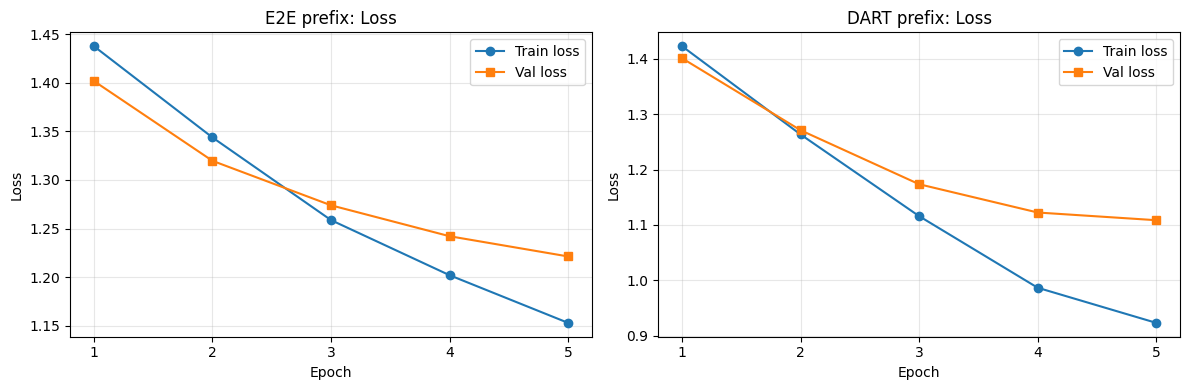

In [ ]:
# ===========================================================================
# Training curves: train vs val loss per epoch
# ===========================================================================
fig, axes = plt.subplots(1, len(histories), figsize=(6 * len(histories), 4), squeeze=False)

for col, (name, history) in enumerate(histories.items()):
    log = training_log(history)
    ax  = axes[0, col]
    ax.plot(log.Epoch, log["Train Loss"], marker="o", label="Train loss")
    ax.plot(log.Epoch, log["Val Loss"],   marker="s", label="Val loss")
    ax.set_title(f"{name.upper()} prefix: Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_xticks(range(1, EPOCHS + 1))
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# One frozen GPT-2
#        │
#        ├── E2E prefix
#        │
#        └── DART prefix

In [ ]:
# ===========================================================================
# One frozen GPT-2, two prefixes attached by name
# ===========================================================================
set_seed(SEED)
base = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device).eval()
base_checksum = weight_checksum(base)

model = PeftModel.from_pretrained(base, "./prefix_e2e", adapter_name="e2e")
model.load_adapter("./prefix_dart", adapter_name="dart")
model.to(device).eval()
print("Prefixes attached:", list(model.peft_config.keys()))

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

Prefixes attached: ['e2e', 'dart']


prefix=none | e2e  | BLEU   6.2
prefix=none | dart | BLEU  10.0
prefix=e2e  | e2e  | BLEU  66.1
prefix=e2e  | dart | BLEU   9.9
prefix=dart | e2e  | BLEU  37.3
prefix=dart | dart | BLEU  42.2


,prefix,task_data,BLEU
0,none,e2e,6.24
1,none,dart,10.03
2,e2e,e2e,66.06
3,e2e,dart,9.92
4,dart,e2e,37.29
5,dart,dart,42.18


Base weights unchanged after inference: True


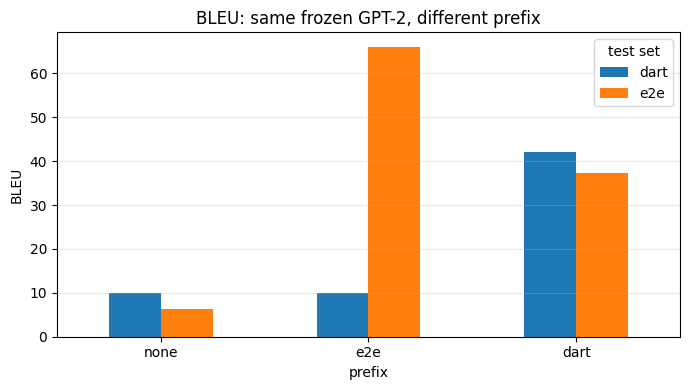

In [ ]:
# ===========================================================================
# Generation quality: no prefix / E2E prefix / DART prefix on both test sets
#   BLEU (NLTK, corpus-level)
# ===========================================================================
rows, outputs = [], {}
for prefix in ["none", "e2e", "dart"]:
    if prefix == "none":
        m = base
    else:
        model.set_adapter(prefix)
        m = model
    for task_name, t in tasks.items():
        full = generate_batch(m, t["test"].source.tolist(), first_line=False)
        hyps = [f.split("\n")[0].strip() for f in full]            # first line used for BLEU
        bleu = score_generation(hyps, t["test"].refs.tolist())
        outputs[(prefix, task_name)] = full                         # full text kept for display
        rows.append({"prefix": prefix, "task_data": task_name, "BLEU": bleu})
        print(f"prefix={prefix:4s} | {task_name:4s} | BLEU {bleu:5.1f}")

results = pd.DataFrame(rows)
display(results.round(2))
print("Base weights unchanged after inference:", math.isclose(base_checksum, weight_checksum(base)))

fig, ax = plt.subplots(figsize=(7, 4))
(results.pivot(index="prefix", columns="task_data", values="BLEU")
        .loc[["none", "e2e", "dart"]]
        .plot(kind="bar", ax=ax, rot=0))
ax.set_title("BLEU: same frozen GPT-2, different prefix")
ax.set_ylabel("BLEU")
ax.set_xlabel("prefix")
ax.legend(title="test set")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ===========================================================================
# Same input, different prefix
# ===========================================================================
W = 14   # label width

def show(label, text):
    lines = [l for l in (text or "").split("\n") if l.strip()] or ["(empty)"]
    print(f"{label:{W}s}:", lines[0])
    for line in lines[1:]:
        print(" " * (W + 1), line)          # continuation lines aligned under the text

for task_name, t in tasks.items():
    src, refs = t["test"].source.iloc[0], t["test"].refs.iloc[0]
    print(f"\n=== {task_name.upper()} example ===")
    show("TABLE", src[:200])
    show("REFERENCE", refs[0])
    for prefix in ["none", "e2e", "dart"]:
        show(prefix.upper() + " prefix", outputs[(prefix, task_name)][0])


=== E2E example ===
TABLE         : name : The Vaults | eatType : restaurant | food : French | priceRange : more than £30 | area : city centre | familyFriendly : no | near : Raja Indian Cuisine
REFERENCE     : The Vaults is an up market French cuisine restaurant located in the City Centre near to the Raja Indian Cuisine restaurant
NONE prefix   : Text:
                Text:
                Text:
                Text:
                Text:
                Text:
                Text:
                Text:
                Text:
                Text:
                Text:
                Text:
                Text:
                Text:
                Text:
                Text:
                Text:
                Text:
                Text:
                Text:
                Text:
E2E prefix    : The Vaults is a restaurant in the city centre near Raja Indian Cuisine. It is not family-friendly and has a price range of more than £30.
DART prefix   : The Vaults is located in the city 

In [ ]:
# ===========================================================================
# Compare: what is actually stored on disk for each task vs GPT-2
# ===========================================================================
gpt2_params = sum(p.numel() for p in base.parameters())

rows = []
for p in ["e2e", "dart"]:
    expected = PREFIX_LEN[p] * base.config.n_layer * 2 * base.config.n_embd
    saved    = load_file(f"./prefix_{p}/adapter_model.safetensors")
    for k, v in saved.items():
        print(f"{p:4s} file -> {k}: {tuple(v.shape)}")
    stored = sum(v.numel() for v in saved.values())
    rows.append({
        "prefix":              p,
        "prefix_len":          PREFIX_LEN[p],
        "BLEU_on_own_task":    results.query("prefix == @p and task_data == @p").BLEU.item(),
        "stored_params":       stored,
        "matches_prefix_only": stored == expected,
        "%_of_gpt2":           100 * stored / gpt2_params,
    })

display(pd.DataFrame(rows).round(4))

e2e  file -> prompt_embeddings: (5, 49152)
dart file -> prompt_embeddings: (10, 49152)


,prefix,prefix_len,BLEU_on_own_task,stored_params,matches_prefix_only,%_of_gpt2
0,e2e,5,66.0590,245760,True,0.0693
1,dart,10,42.1845,491520,True,0.1385


### **Summary**

* **Prefix tuning** keeps GPT-2 **frozen** and trains only a small **prefix** of virtual key/value vectors for each task, inserted into every attention layer.
* Two prefixes, **E2E** and **DART**, are trained **independently** and then attached to **one shared copy of GPT-2**; switching the prefix switches the task.
* Each prefix performs best on its own task (BLEU **66.05** on E2E, **42.2** on DART), close to the paper's 69.7 and 46.4, while the frozen model without a prefix fails.

### **Future Directions**

1. **Train on the full E2E / DART training sets** and use **beam search (beam 5)** as in the paper.
2. **Vary the prefix length** to reproduce the paper's prefix-length trend.
3. **Train without the MLP** (`prefix_projection=False`) and compare training stability.
4. **Compare with adapters and full fine-tuning** on the same two tasks.

In [ ]:
###--------------END-------------###